In [27]:
import sklearn
import numpy as np
import pandas as pd
import os
import datetime as dt
import sys 
import importlib
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from collections import Counter
sklearn.set_config(enable_metadata_routing=False)
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_selector as selector
from xgboost import XGBClassifier, XGBRegressor
import time 
import pandas as pd
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.stats import pearsonr
import plotly.express as px
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
import numpy as np
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_absolute_error
import seaborn as sns
import pickle


############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables
from scripts import feature_selection as fs
from scripts import clustering as cl

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(cl)

# Filepaths
brighten_dir = paths.DATA
sub_dir = paths.SUB_DFS
results_dir = paths.RESULTS



################ DEFINE column variables from data ###################
from scripts.variables import id_columns, baseline_cols, fully_missing_cols
from scripts.variables import daily_v2_weather, keep_weather 

print(baseline_cols)
# Define label variables
df_names = ['v1_day', 'v2_day', 'v1_week', 'v2_week']
aggregate_dfs = ['alldays_df','week_df']
# Update endings list if order changes
coverage_threshold=0.7

########################################## MODELS #######################################


# Models
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
# Dummy baseline model
class GroupMeanRegressor(BaseEstimator, RegressorMixin):
	def fit(self, X, y, groups):
		self.group_means_ = y.groupby(groups.squeeze()).mean().squeeze()
		self.global_mean_ = y.mean().squeeze()
		return self
	
	def predict(self, X, groups):
		return groups.squeeze().map(self.group_means_).fillna(self.global_mean_).values

# Pearson scorer
def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

models = {
	'Random Forest': RandomForestRegressor(random_state=42),
	'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
	'Hist Gradient Boost': HistGradientBoostingRegressor(),
	'Group Mean': GroupMeanRegressor(),
	'Ridge': Ridge(alpha=1.0)
}
from sklearn.metrics import make_scorer
from scipy.stats import pearsonr

def pearsonr_scorer(y_true, y_pred):
	return pearsonr(y_true, y_pred)[0]

scoring_metrics = {
	'r2': 'r2',
	'neg_mae': 'neg_mean_absolute_error',
	'neg_rmse': 'neg_root_mean_squared_error',
}





['gad7_1', 'gad7_2', 'gad7_3', 'gad7_4', 'gad7_5', 'gad7_6', 'gad7_7', 'gad7_8', 'gad7_sum', 'gad_cat', 'phq9_1_base', 'phq9_2_base', 'phq9_3_base', 'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base', 'phq9_8_base', 'phq9_9_base', 'phq9_sum_base', 'cid', 'bin_clin', 'bipolar', 'scz', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'gender', 'education', 'working', 'income_satisfaction', 'incomelastyear', 'marital_status', 'race', 'age', 'heard_about_us', 'device', 'startdate', 'study_arm', 'study', 'income_lastyear', 'user_phone_type', 'alc_1', 'alc_2', 'alc_3', 'alc_sum', 'alc_cat', 'mhs_1', 'mhs_2', 'mhs_3', 'mhs_4', 'mhs_5', 'mhs_sum', 'cohort_Akili', 'cohort_Health tips', 'cohort_PST']


In [29]:
# Just so i can view them :3
v1day_df = pd.read_csv(os.path.join(brighten_dir, 'v1_day_trainval_transformed.csv'))
v1week_df = pd.read_csv(os.path.join(brighten_dir, 'v1_week_trainval_pca.csv'))
v2day_df = pd.read_csv(os.path.join(brighten_dir, 'v2_day_trainval_pca.csv'))
v2week_df = pd.read_csv(os.path.join(brighten_dir, 'v2_week_trainval_pca.csv'))


## Find and Cols which are >80% correlated, to drop

### Sensor and Survey Cols

In [30]:
for name in ['v1_day', 'v2_day', 'v1_week', 'v2_week']:
	print(f'\n\n########## {name}: #########')
	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
	print(f'Reading in df from {os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')}')

	numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
	drop_nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
	drop_dup_dumb_cols = [col for col in df.columns if '.1' in col or '.2' in col or '.3' in col or 'Unnamed' in col]
	drop_baseline_cols = [col for col in df.columns if any(item in col for item in baseline_cols)]
	drop_fully_missing_cols = [col for col in df.columns if col in fully_missing_cols]
	drop_time_cols = [col for col in df.columns if any(item in col for item in ['dt','date','day','week','month','season'])]
	drop_non_hr_cols = [col for col in df.columns if f'{col}_hr' in df.columns]
	df_clean = df.drop(columns=[col for col in df.columns if col in drop_nonnumeric_cols+drop_dup_dumb_cols+drop_baseline_cols+drop_time_cols+drop_non_hr_cols+drop_fully_missing_cols])
	
	# ---- Drop WEATHER ----
	df_clean = df_clean.drop(columns=[col for col in df_clean.columns if col in daily_v2_weather and col not in keep_weather])

	df_corr = df_clean.corr()

	# ---- Show Correlation Matrix ----
	# plt.figure(figsize=(6, 5))  # width=12, height=10 inches
	# sns.heatmap(df_corr, cmap="coolwarm", center=0)
	#plt.show()

	highly_correlated = []

	pos_corr = df_corr.where(df_corr>0.8)
	pos_corr = pos_corr.where(pos_corr!=1)
	pos_corr=pos_corr.dropna(how='all')	
	if len(pos_corr)>0:
		# ---- Show filtered positive correlation matrix ----
		# sns.heatmap(pos_corr, cmap="coolwarm", center=0.7)
		# plt.show()
		for c, row in pos_corr.iterrows():
			if len(row.dropna())>0:
				pair = [c, row.dropna().index[0]]
				upair = [row.dropna().index[0], c]
				if not pair in highly_correlated and not upair in highly_correlated:
					highly_correlated.append(pair)
	
	neg_corr = df_corr.where(df_corr<-0.8)
	neg_corr = neg_corr.where(neg_corr!=1)
	neg_corr=neg_corr.dropna(how='all')
	if len(neg_corr)>0:
		# Show filtered negative correlation matrix
		# sns.heatmap(neg_corr, cmap="coolwarm", center=-0.7)
		# plt.show()
		for c, row in neg_corr.iterrows():
			if len(row.dropna())>0:
				pair = [c, row.dropna().index[0]]
				upair = [row.dropna().index[0], c]
				if not pair in highly_correlated and not upair in highly_correlated:
					highly_correlated.append(pair)
	for pair in highly_correlated:
		print(pair)

	




########## v1_day: #########
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv
['sms_length', 'aggregate_communication']
['sms_count', 'sms_length']
['phq2_1', 'phq2_2']
['phq2_sum', 'phq2_1']
['phq9_sum', 'phq9_cat']
['phq9_bin', 'phq9_cat']


########## v2_day: #########
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv
['distance_powered_vehicle_hr', 'hours_powered_vehicle_hr']
['hours_walking_hr', 'distance_walking_hr']
['hours_active_hr', 'distance_active_hr']
['temp_median', 'dew_point_median']
['phq2_1', 'phq2_sum']
['phq2_2', 'phq2_sum']
['phq9_2', 'phq9_sum']
['phq9_cat', 'phq9_sum']
['phq9_bin', 'phq9_cat']


########## v1_week: #########
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_project

**V1 Day**
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv
* ['sms_count', 'aggregate_communication']
* ['sms_count', 'sms_length']
* ['phq2_1', 'phq2_2']
* ['phq2_sum', 'phq2_1']

- -> I'll keep unreturned_calls, sms_count just for interpretability (the others are created features by the team)

- -> phq2 i'm tempted to leave both 1 and 2 in, and take out sum, since they're different questions. but i should investigate further how many people diverge or mark the same on both.

### Drop cols V1: 
**v1**: aggregate_communication, sms_length

**V2 Day**
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv
* ['hours_walking_hr', 'distance_walking_hr']
* ['hours_high_speed_transportation_hr', 'distance_high_speed_transportation_hr']
* ['hours_powered_vehicle_hr', 'distance_powered_vehicle_hr']
*  ['hours_active_hr', 'distance_active_hr']

- -> i'll keep hours for interpretability, and because distance depends on rate, whereas hours is an experiential measure which should have more to do with wellbeing, theoretically.

### Drop cols V2
**v2**: distance_walking_hr, distance_high_speed_transportation_hr, distance_powered_vehicle_hr, distance_active_hr

In [16]:
drop_corr_cols_v1 = ['aggregate_communication', 'sms_length']
drop_corr_cols_v2 = ['distance_walking_hr', 'distance_high_speed_transportation_hr', 'distance_powered_vehicle_hr', 'distance_active_hr']

# Also added to variables.py

### Weather Cols

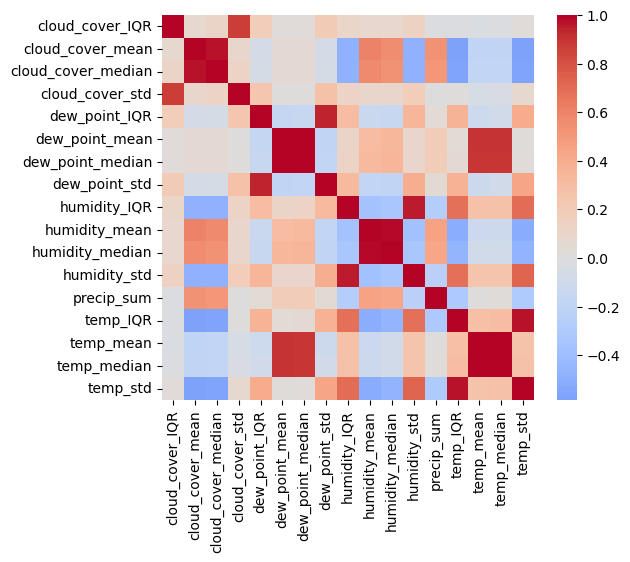

16


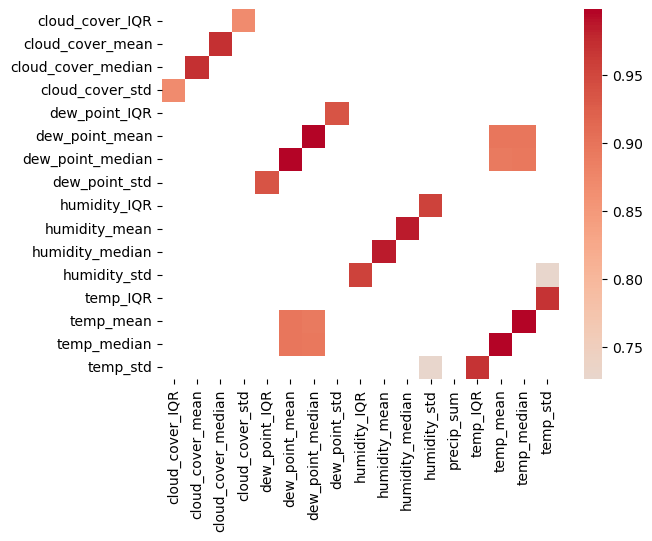

In [17]:
weather = a_v2day_pca_df.drop(columns=[col for col in a_v2day_pca_df.columns if col not in daily_v2_weather])
weather = weather.sort_index(axis=1)
weather_corr = weather.corr()

plt.figure(figsize=(6, 5))  # width=12, height=10 inches
sns.heatmap(weather_corr, cmap="coolwarm", center=0)
plt.show()


pos_corr = weather_corr.where(weather_corr>0.7)
pos_corr = pos_corr.where(pos_corr!=1)
pos_corr=pos_corr.dropna(how='all')	
if len(pos_corr)>0:
	print(len(pos_corr))
	sns.heatmap(pos_corr, cmap="coolwarm", center=0.7)
	plt.show()

	
neg_corr = weather_corr.where(weather_corr<-0.7)
neg_corr = neg_corr.where(neg_corr!=1)
neg_corr=neg_corr.dropna(how='all')
if len(neg_corr)>0:
	print(len(neg_corr))
	sns.heatmap(neg_corr, cmap="coolwarm", center=-0.7)
	plt.show()






### Ok so ask expected, all the same metrics are correlated with each other. So we'll only keep on from each of them. I guess we'll keep the one with the highest ANOVA/LME score from each of them. 

In [18]:
## Define keep_weather_cols below

## Subject-Level ANOVA for V2, Averaged Across All Subjects (for weather column choice)

In [31]:
## Anova for feature analysis
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
import textwrap

# ---- EDIT PARAMS ------
n_features = 10 # Choose number of features/scores to save from the ANOVA
n_subjects_show = 0 # Choose number of subjects' ANOVA scores to see in graphs
n_features_show = 10 # Choose number of features to see in graphs
show_means = True # Choose whether to visualize mean scores for features across all subjects
verbose = False
# --------------------

anova_features = {}
top_subj_features = {}
	
for y_col in ['phq2_sum','phq9_sum']:
	anova_features[y_col] = {}
	top_subj_features[y_col]={}

	for name in ['v2_day','v2_week']:
		subjects_shown_count=0
		subjects_skipped=0
		top_subj_features[y_col][name] = {}
		#print(f'################ {name} ###############')
		df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')) #use transformed to have NOT imputed data
		df['num_id'] = pd.to_numeric(df['num_id'])
		numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
		drop_nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
		drop_dup_dumb_cols = [col for col in df.columns if '.1' in col or '.2' in col or '.3' in col or 'Unnamed' in col]
		drop_baseline_cols = [col for col in df.columns if any(item in col for item in baseline_cols)]
		drop_fully_missing_cols = [col for col in df.columns if col in fully_missing_cols]
		drop_time_cols = [col for col in df.columns if any(item in col for item in ['dt','date','day','week','month','season'])]
		# Too correlated cols:
		drop_too_corr_cols = [col for col in df.columns if col in drop_corr_cols_v1+drop_corr_cols_v2]
		drop_non_hr_cols = [col for col in df.columns if f'{col}_hr' in df.columns]
		df_clean = df.drop(columns=[col for col in df.columns if col in drop_nonnumeric_cols+drop_dup_dumb_cols+drop_baseline_cols+drop_time_cols+drop_non_hr_cols+drop_too_corr_cols+drop_fully_missing_cols])

		for sub, sub_df in df_clean.groupby('num_id'):		
			
			df_cov = sub_df.loc[:, sub_df.notna().mean() > 0.7]
			df_cov = df_cov.copy()
			if y_col not in df_cov.columns:
				df_cov[y_col] = sub_df[y_col].copy()
			#print(f'Not including these columns in X, not enough coverage: ', [col for col in sub_df.columns if col not in df_cov.columns])
			df_full = df_cov.dropna()
			#print(f'Shape before dropna: {df_cov.shape}, shape afer dropna: {df_full.shape}')
			rows = len(df_full)
			columns_dropped = df_cov.shape[0] - df_full.shape[0]
			columns_remaining = df_full.shape[0]
			min_rows = 6 if 'week' in name else 15
			if rows <= min_rows:
				if verbose: print(f'Skipping {sub}, only {rows} rows.')
				subjects_skipped+=1
				continue # skip small samples
			if columns_remaining < 4:
				if verbose: print(f'Skipping {sub}, only {columns_remaining} columns (dropped {columns_dropped}).')
				subjects_skipped+=1
				continue #skip insufficient features

			# Separate X and y
			selector = SelectKBest(score_func=f_classif, k=2)
			if 'phq2' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq' in col])
			if 'phq9' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq9' in col])
			X_num = X.select_dtypes(include=('int64','float64'))
			# print(f'Not including these columns in X, not numeric: ', [col for col in X.columns if col not in X_num.columns])
			
			y = df_full[y_col].copy()
			if y.nunique() < 2 or y.var() < 0.001:
				if verbose: print(f'Skipping sub {sub}: 0 variance in y')
				subjects_skipped+=1
				continue
			if y.std() < 0.1:
				if verbose: print(f'Skipping sub {sub}, low variance in y')
				subjects_skipped+=1
				continue



			# --- Drop constant (zero-variance) features ---
			var_selector = VarianceThreshold(threshold=1e-10)
			try:
				X_var = pd.DataFrame(
					var_selector.fit_transform(X_num),
					columns=X_num.columns[var_selector.get_support()],
					index=X_num.index
				)
			except Exception as e:
				if verbose: print(f'Skipping sub {sub}, Exception on VarianceThreshold: {e}')
				subjects_skipped+=1
				continue 

			if X_var.shape[1] < 2:
				if verbose: print(f'Skipping sub {sub}, only {X_var.shape[1]} features after dropping zero-variance.')
				subjects_skipped+=1
				continue

			X_new = selector.fit_transform(X_var, y)

			# Show scores
			anova_scores = pd.DataFrame({
				'feature': X_var.columns,
				'f_score': selector.scores_,
				'p_value': selector.pvalues_
			}).sort_values('f_score', ascending=False)

			#print(anova_scores)
			
			# --- Save Features --- 
			top_n = 10  # number of top features to save
			top_features_sub = anova_scores.head(top_n)
			top_subj_features[y_col][name][sub] = top_features_sub['feature'].to_list()

			# --- Visualize Scores for Subjects ---

			if subjects_shown_count < n_subjects_show:
				fig = plt.figure(figsize=(5, 4))
				plt.barh(top_features_sub['feature'], top_features_sub['f_score'], color='skyblue')
				plt.xlabel('F-score (ANOVA)')
				plt.ylabel('Feature')
				plt.suptitle(f'{name} subject: Top {top_n} Features for subject {sub} by ANOVA F-score')
				plt.gca().invert_yaxis()

				# Wrap columns into a readable multi-line string
				cols_str = ', '.join(X_var.columns.to_list())
				wrapped = textwrap.fill(cols_str, width=100)
				label = f'Columns available:\n{wrapped}'

				plt.figtext(
					0.01, -0.02,          # x, y in figure coords (below the axes)
					label,
					fontsize=7,
					verticalalignment='top',
					bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
				)

				plt.tight_layout()
				plt.subplots_adjust(bottom=0.02 + 0.013 * wrapped.count('\n'))  # grow bottom margin with line count
				plt.show()
				subjects_shown_count += 1


	# --- Summarize across subjects ---
	for name in top_subj_features[y_col].keys():
		all_feats = [feat for sublist in top_subj_features[y_col][name].values() for feat in sublist]
		counts = Counter(all_feats)
		top_common = pd.DataFrame(counts.most_common(15), columns=['feature', 'count'])
		
		# --- Visualize Mean Scores Across Subjects ---
		if show_means:
			fig = px.bar(top_common, x='feature', y='count', title=f'Top 15 sig. features to {y_col}  for {name}')
			fig.show()

		if verbose: print(f'Adding to {name} for {y_col}: {top_common['feature'].to_list()}')
		anova_features[y_col][name] = top_common['feature'].to_list()

		subjects_used = len(list(top_subj_features[y_col][name].keys()))
		subjects = subjects_used + subjects_skipped

		print(f'For {name}: {subjects_used} used of {subjects}')
	


Run on: Fri 29 May 2026, 02:17PM


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


For v2_day: 104 used of 145


For v2_week: 106 used of 147


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs

For v2_day: 82 used of 209


For v2_week: 20 used of 147


### From this, we'll keep keep_weather = ["dew_point_median", "temp_median", "precip_sum"]. It seems like the analyses are getting skewed for V2_day because daily everyone has weather but not everyone has the others. 

## Re-run ANOVA for V2 (only 3 kept weather, not too-correlated cols, etc)

Run on: Fri 29 May 2026, 02:17PM
################ v2_day ###############


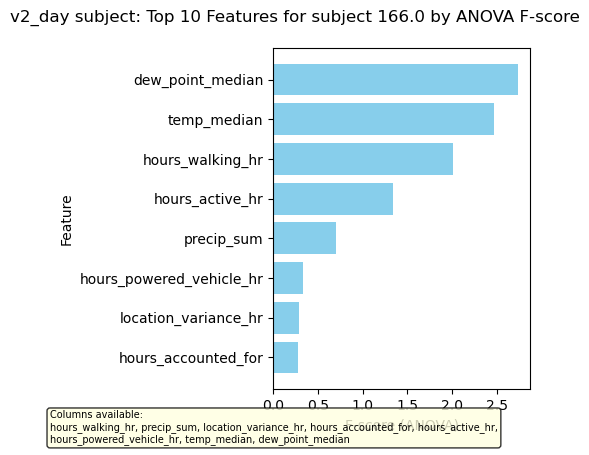

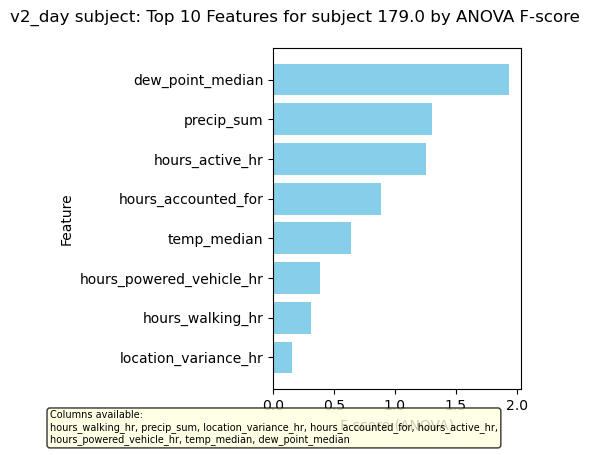

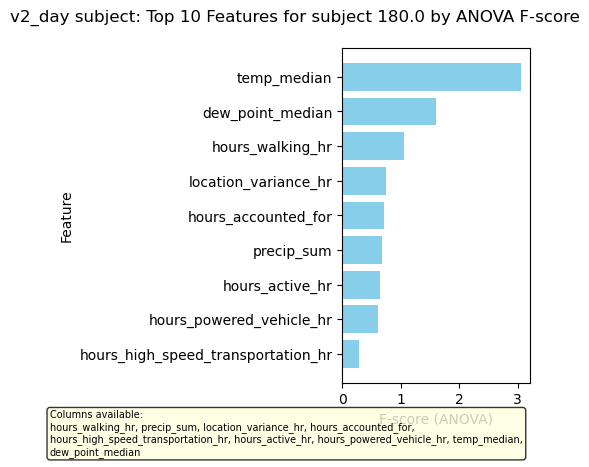

################ v2_week ###############


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


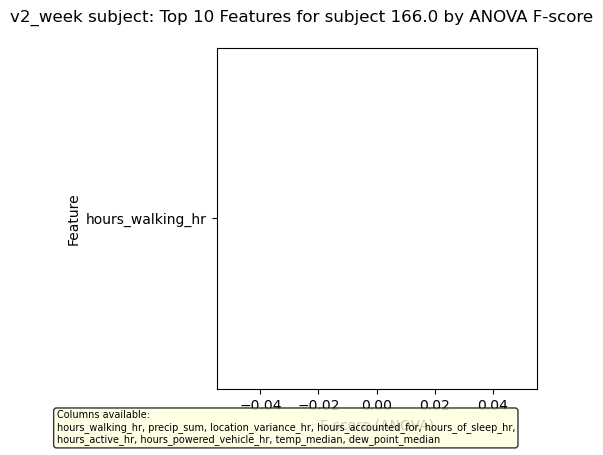

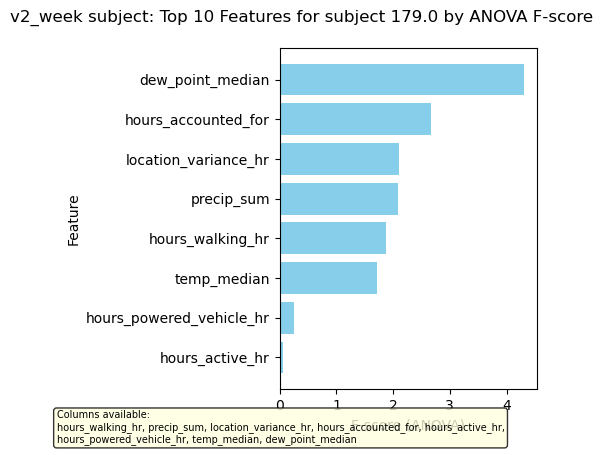

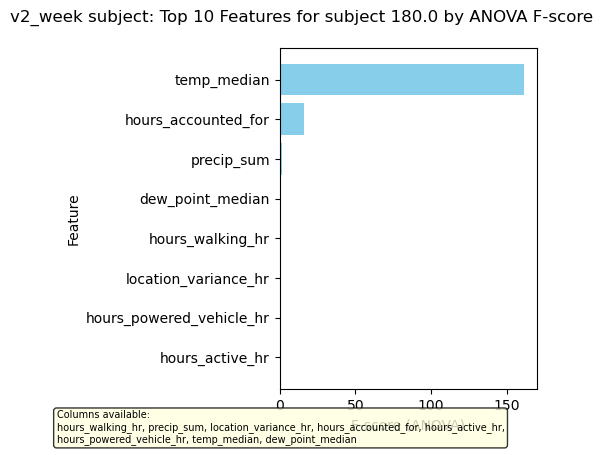

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj

For v2_day: 104 used of 145


For v2_week: 106 used of 147
################ v2_day ###############


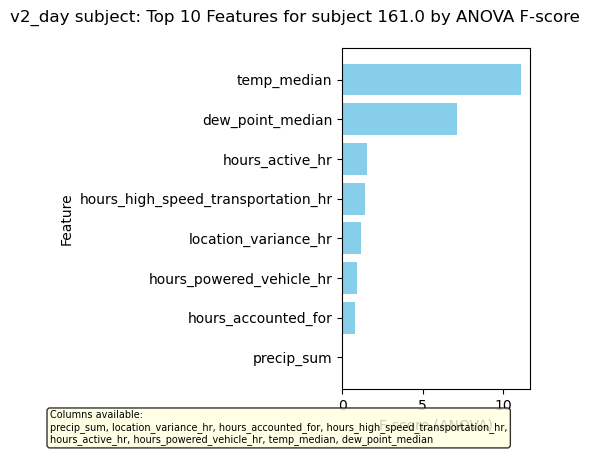

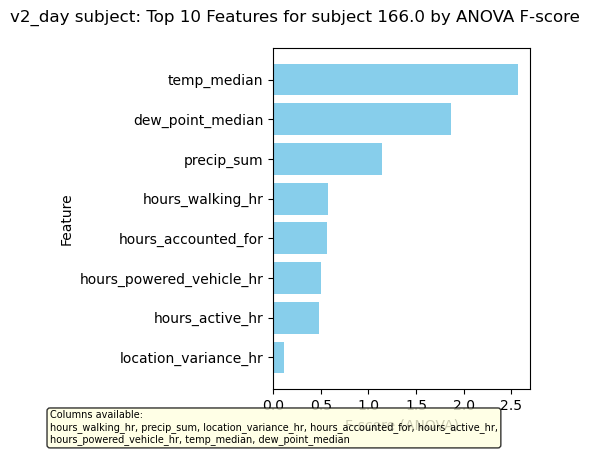

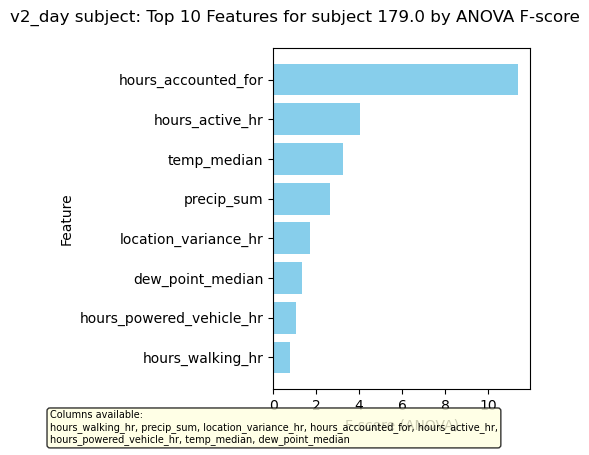

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs

################ v2_week ###############


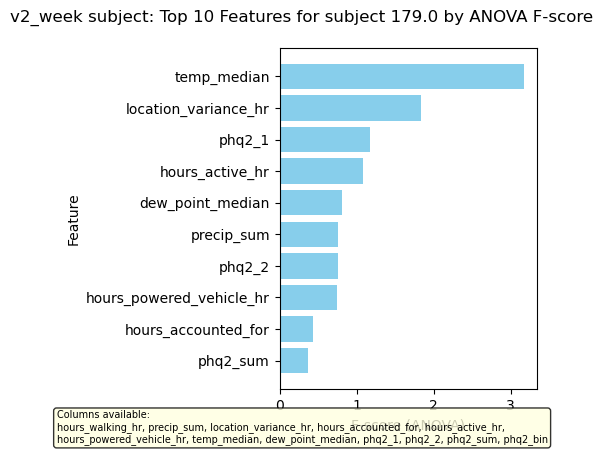

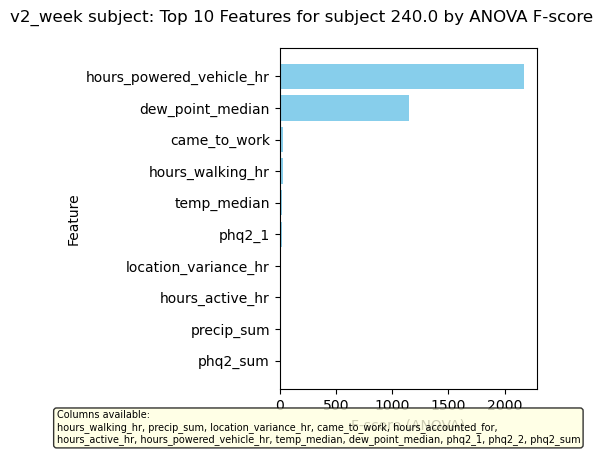

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


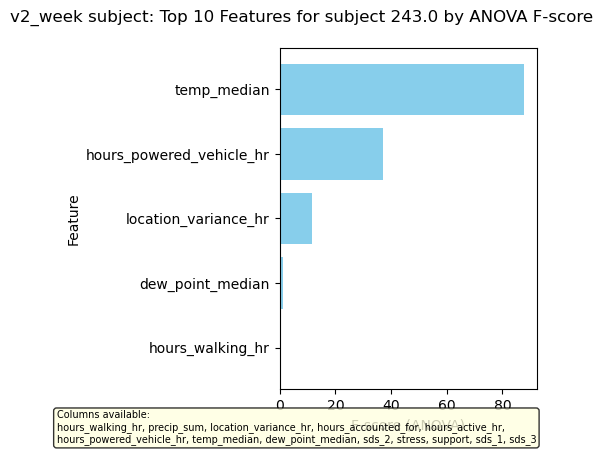

/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/klj9278/minic

For v2_day: 82 used of 209


For v2_week: 20 used of 147


In [ ]:
## Anova LIMITED WEATHER analysis
keep_weather = ["dew_point_median", "temp_median", "precip_sum"]
# also added to variables.py

print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
import textwrap

# ---- EDIT PARAMS ------
n_features = 10 # Choose number of features/scores to save from the ANOVA
n_subjects_show = 3 # Choose number of subjects' ANOVA scores to see in graphs
n_features_show = 10 # Choose number of features to see in graphs
show_means = True # Choose whether to visualize mean scores for features across all subjects
verbose = False
# --------------------

	
for y_col in ['phq2_sum','phq9_sum']:

	for name in ['v2_day','v2_week']:
		subjects_shown_count=0
		subjects_skipped=0
		print(f'################ {name} ###############')
		df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')) #use transformed to have NOT imputed data
		
		numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
		drop_nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
		drop_dup_dumb_cols = [col for col in df.columns if '.1' in col or '.2' in col or '.3' in col or 'Unnamed' in col]
		drop_baseline_cols = [col for col in df.columns if any(item in col for item in baseline_cols)]
		drop_fully_missing_cols = [col for col in df.columns if col in fully_missing_cols]
		drop_time_cols = [col for col in df.columns if any(item in col for item in ['dt','date','day','week','month','season'])]
		# Too correlated cols
		drop_drop_too_corr_cols = [col for col in df.columns if col in drop_corr_cols_v1+drop_corr_cols_v2]
		drop_non_hr_cols = [col for col in df.columns if f'{col}_hr' in df.columns]
		# Drop WEATHER
		drop_weather_cols = [col for col in daily_v2_weather if col in df.columns and col not in keep_weather]
		df_clean = df.drop(columns=[col for col in df.columns if col in drop_nonnumeric_cols+drop_dup_dumb_cols+drop_baseline_cols+drop_time_cols+drop_non_hr_cols+drop_drop_too_corr_cols+drop_weather_cols+drop_fully_missing_cols])
		
		

		for sub, sub_df in df_clean.groupby('num_id'):

			df_cov = sub_df.loc[:, sub_df.notna().mean() > 0.7]
			df_cov = df_cov.copy()
			if y_col not in df_cov.columns:
				df_cov[y_col] = sub_df[y_col].copy()
			#print(f'Not including these columns in X, not enough coverage: ', [col for col in sub_df_anova.columns if col not in df_cov.columns])
			df_full = df_cov.dropna()
			#print(f'Shape before dropna: {df_cov.shape}, shape afer dropna: {df_full.shape}')
			rows = len(df_full)
			columns_dropped = df_cov.shape[0] - df_full.shape[0]
			columns_remaining = df_full.shape[0]
			min_rows = 6 if 'week' in name else 15
			if rows <= min_rows:
				if verbose: print(f'Skipping {sub}, only {rows} rows.')
				subjects_skipped+=1
				continue # skip small samples
			if columns_remaining < 4:
				if verbose: print(f'Skipping {sub}, only {columns_remaining} columns (dropped {columns_dropped}).')
				subjects_skipped+=1
				continue #skip insufficient features

			# Separate X and y
			selector = SelectKBest(score_func=f_classif, k=2)
			if 'phq2' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq' in col])
			if 'phq9' in y_col:
				X = df_full.drop(columns=[col for col in df_full.columns if 'phq9' in col])
			X_num = X.select_dtypes(include=('int64','float64'))
			# print(f'Not including these columns in X, not numeric: ', [col for col in X.columns if col not in X_num.columns])
			
			y = df_full[y_col].copy()
			if y.nunique() < 2 or y.var() < 0.001:
				if verbose: print(f'Skipping sub {sub}: 0 variance in y')
				subjects_skipped+=1
				continue
			if y.std() < 0.1:
				if verbose: print(f'Skipping sub {sub}, low variance in y')
				subjects_skipped+=1
				continue



			# --- Drop constant (zero-variance) features ---
			var_selector = VarianceThreshold(threshold=1e-10)
			try:
				X_var = pd.DataFrame(
					var_selector.fit_transform(X_num),
					columns=X_num.columns[var_selector.get_support()],
					index=X_num.index
				)
			except Exception as e:
				if verbose: print(f'Skipping sub {sub}, Exception on VarianceThreshold: {e}')
				subjects_skipped+=1
				continue 

			if X_var.shape[1] < 2:
				if verbose: print(f'Skipping sub {sub}, only {X_var.shape[1]} features after dropping zero-variance.')
				subjects_skipped+=1
				continue

			X_new = selector.fit_transform(X_var, y)

			# Show scores
			anova_scores = pd.DataFrame({
				'feature': X_var.columns,
				'f_score': selector.scores_,
				'p_value': selector.pvalues_
			}).sort_values('f_score', ascending=False)

			#print(anova_scores)
			
			# --- Save Features --- 
			top_n = 10  # number of top features to save
			top_features_sub = anova_scores.head(top_n)
		
			top_subj_features[y_col][name][sub] = top_features_sub['feature'].to_list()

			# --- Visualize Scores for Subjects ---

			if subjects_shown_count < n_subjects_show:
				fig = plt.figure(figsize=(5, 4))
				plt.barh(top_features_sub['feature'], top_features_sub['f_score'], color='skyblue')
				plt.xlabel('F-score (ANOVA)')
				plt.ylabel('Feature')
				plt.suptitle(f'{name} subject: Top {top_n} Features for subject {sub} by ANOVA F-score')
				plt.gca().invert_yaxis()

				# Wrap columns into a readable multi-line string
				cols_str = ', '.join(X_var.columns.to_list())
				wrapped = textwrap.fill(cols_str, width=100)
				label = f'Columns available:\n{wrapped}'

				plt.figtext(
					0.01, -0.02,          # x, y in figure coords (below the axes)
					label,
					fontsize=7,
					verticalalignment='top',
					bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
				)

				plt.tight_layout()
				plt.subplots_adjust(bottom=0.02 + 0.013 * wrapped.count('\n'))  # grow bottom margin with line count
				plt.show()
				subjects_shown_count += 1


	# --- Summarize across subjects ---
	for name in top_subj_features[y_col].keys():
		if 'v1' in name:
			continue
		all_feats = [feat for sublist in top_subj_features[y_col][name].values() for feat in sublist]
		counts = Counter(all_feats)
		top_common = pd.DataFrame(counts.most_common(15), columns=['feature', 'count'])
		
		# --- Visualize Mean Scores Across Subjects ---
		if show_means:
			fig = px.bar(top_common, x='feature', y='count', title=f'ANOVA Top 15 sig. features to {y_col}  for {name}')
			fig.show()

		if verbose: print(f'Adding to {name} for {y_col}: {top_common['feature'].to_list()}')
		anova_features[y_col][name] = top_common['feature'].to_list()

		subjects_used = len(list(top_subj_features[y_col][name].keys()))
		subjects = subjects_used + subjects_skipped

		print(f'For {name}: {subjects_used} used of {subjects}')
	


## Linear Mixed-Effects Model for feature analysis


In [ ]:
## Linear Mixed-Effects Model for feature analysis
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

import pandas as pd
import numpy as np
from collections import Counter
import statsmodels.formula.api as smf
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# ---- EDIT PARAMS ------
n_features_show = 15       # Number of top features to display in summary plots
show_means = True          # Whether to visualize population-level feature importance
min_subjects_per_feature = 3  # Feature must appear in at least this many subjects' data
coverage_threshold = 0.7   # Min non-null proportion to keep a column
# --------------------

lme_features = {}

for y_col in ['phq2_sum', 'phq9_sum']:
	lme_features[y_col] = {}

	for name in ['v1_day', 'v2_day', 'v1_week', 'v2_week']:
		print(f'################ {name} ###############')
		df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_transformed.csv'))
		print(f'Reading in df from {os.path.join(brighten_dir, f'{name}_trainval_transformed.csv')}')

		numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
		drop_nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
		drop_dup_dumb_cols = [col for col in df.columns if '.1' in col or '.2' in col or '.3' in col or 'Unnamed' in col]
		drop_baseline_cols = [col for col in df.columns if any(item in col for item in baseline_cols)]
		drop_fully_missing_cols = [col for col in df.columns if col in fully_missing_cols]
		drop_time_cols = [col for col in df.columns if any(item in col for item in ['dt','date','day','week','month','season'])]
		
		# Too correlated cols
		drop_drop_too_corr_cols = [col for col in df.columns if col in drop_corr_cols_v1+drop_corr_cols_v2]
		drop_non_hr_cols = [col for col in df.columns if f'{col}_hr' in df.columns]
		# Drop WEATHER
		drop_weather_cols = [col for col in daily_v2_weather if col in df.columns and col not in keep_weather]
		df_clean = df.drop(columns=[col for col in df.columns if col in drop_nonnumeric_cols+drop_dup_dumb_cols+drop_baseline_cols+drop_time_cols+drop_non_hr_cols+drop_drop_too_corr_cols+drop_weather_cols+drop_fully_missing_cols])
		

		# ---- Keep columns with sufficient coverage across the whole dataset ----
		df_clean = df_clean.loc[:, df_clean.notna().mean() > coverage_threshold]
		if y_col not in df_clean.columns:
			df_clean[y_col] = df[y_col]

		# ---- Drop PHQ co-predictors depending on target ----
		if 'phq2' in y_col:
			X_cols = [col for col in df_clean.columns if 'phq' not in col and col != 'num_id']
		else:
			X_cols = [col for col in df_clean.columns if 'phq9' not in col and col != 'num_id']

		# Keep numeric features only, but explicitly preserve num_id and target
		feature_cols_numeric = df_clean[X_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
		df_model = df_clean[feature_cols_numeric + [y_col, 'num_id']].copy()
		df_model = df_model.dropna()

		# ---- Drop zero/near-zero variance features ----
		feature_cols = [col for col in df_model.columns if col not in [y_col, 'num_id']]
		var_selector = VarianceThreshold(threshold=1e-10)
		X_var = pd.DataFrame(
			var_selector.fit_transform(df_model[feature_cols]),
			columns=np.array(feature_cols)[var_selector.get_support()],
			index=df_model.index
		)

		# ---- Require feature appears in enough subjects' rows ----
		subject_coverage = df_model[['num_id']].join(X_var).groupby('num_id').count()
		valid_features = subject_coverage.columns[
			(subject_coverage > 0).sum() >= min_subjects_per_feature
		].tolist()
		X_var = X_var[valid_features]

		if X_var.shape[1] < 2:
			print(f'  Skipping {name}/{y_col}: too few valid features after filtering.')
			continue

		# ---- Standardize features (LME coefficients are comparable when scaled) ----
		scaler = StandardScaler()
		X_scaled = pd.DataFrame(
			scaler.fit_transform(X_var),
			columns=X_var.columns,
			index=X_var.index
		)

		df_lme = X_scaled.copy()
		df_lme[y_col] = df_model[y_col].values
		df_lme['num_id'] = df_model['num_id'].values

		# ---- Fit one LME per feature (univariate), random intercept per subject ----
		# Univariate approach avoids multicollinearity and is standard for feature selection
		lme_results = []
		for feat in X_scaled.columns:
			try:
				formula = f'{y_col} ~ {feat}'
				model = smf.mixedlm(formula, df_lme, groups=df_lme['num_id'])
				result = model.fit(reml=False, method='lbfgs', disp=False)

				lme_results.append({
					'feature': feat,
					'coefficient': abs(result.fe_params[feat]),  # abs for ranking magnitude
					'z_score': abs(result.tvalues[feat]),
					'p_value': result.pvalues[feat],
					'converged': result.converged
				})
			except Exception as e:
				# Skip features where the model fails to converge or errors out
				print(f'  LME failed for {feat}: {e}')

		if not lme_results:
			print(f'  No LME results for {name}/{y_col}.')
			continue

		lme_scores = (
			pd.DataFrame(lme_results)
			.query('converged == True')
			.sort_values('z_score', ascending=False)
			.reset_index(drop=True)
		)

		print(lme_scores.head(n_features_show).to_string(index=False))

		top_features_list = lme_scores.head(n_features_show)['feature'].tolist()
		lme_features[y_col][name] = top_features_list

		# ---- Visualize population-level feature importance ----
		if show_means:
			fig = px.bar(
				lme_scores.head(n_features_show),
				x='feature', y='z_score',
				error_y=None,
				title=f'LME Top {n_features_show} features for {y_col} | {name} (LME z-score)',
				labels={'z_score': '|z-score| (fixed effect)', 'feature': 'Feature'}
			)
			fig.show()

Run on: Fri 29 May 2026, 02:17PM
################ v1_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/

              feature  coefficient  z_score  p_value  converged
  missed_interactions     0.022361 2.395779 0.016585       True
        call_duration     0.023816 2.347803 0.018885       True
interaction_diversity     0.020527 1.790946 0.073302       True
     unreturned_calls     0.012314 1.359120 0.174109       True
           call_count     0.010123 0.848665 0.396068       True
            sms_count     0.001688 0.133486 0.893809       True


################ v2_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv


/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/klj9278/miniconda3/envs/brighten/

...

################ v2_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_week_trainval_transformed.csv
                           feature  coefficient  z_score  p_value  converged
                       temp_median     0.061942 1.490964 0.135971       True
                  hours_walking_hr     0.039257 1.487376 0.136916       True
hours_high_speed_transportation_hr     0.035857 1.444470 0.148607       True
                 hours_of_sleep_hr     0.024986 0.967059 0.333515       True
                        precip_sum     0.024125 0.953964 0.340102       True
          hours_powered_vehicle_hr     0.021295 0.718452 0.472479       True
                   hours_active_hr     0.019822 0.702490 0.482374       True
                      came_to_work     0.027066 0.648469 0.516682       True
              location_variance_hr     0.010568 0.396364 0.691836       True
              

################ v1_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_day_trainval_transformed.csv
              feature  coefficient  z_score  p_value  converged
  missed_interactions     0.042702 4.256677 0.000021       True
     unreturned_calls     0.037098 3.814674 0.000136       True
             phq2_bin     0.034240 3.015951 0.002562       True
           call_count     0.022240 1.865208 0.062152       True
interaction_diversity     0.021078 1.754701 0.079310       True
             phq2_sum     0.014593 1.257271 0.208656       True
               phq2_1     0.014163 1.250685 0.211049       True
            sms_count     0.017748 1.215305 0.224250       True
               phq2_2     0.012261 1.088310 0.276458       True
        call_duration     0.008986 0.820397 0.411990       True


################ v2_day ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_day_trainval_transformed.csv
                           feature  coefficient  z_score  p_value  converged
                       temp_median     0.030904 1.822395 0.068395       True
          hours_powered_vehicle_hr     0.015453 1.483547 0.137929       True
                      came_to_work     0.015660 1.483468 0.137950       True
               hours_accounted_for     0.012076 1.257236 0.208668       True
                        precip_sum     0.010082 1.175107 0.239952       True
                   hours_active_hr     0.011558 1.103445 0.269834       True
                  dew_point_median     0.009779 0.683739 0.494140       True
              location_variance_hr     0.005583 0.581892 0.560639       True
hours_high_speed_transportation_hr     0.002483 0.299748 0.764369       True


################ v1_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v1_week_trainval_transformed.csv
              feature  coefficient   z_score      p_value  converged
             phq2_sum     0.405434 11.174793 5.417655e-29       True
               phq2_1     0.377145 10.703171 9.835367e-27       True
               phq2_2     0.369466 10.132711 3.955279e-24       True
             phq2_bin     0.346686  9.702173 2.951456e-22       True
      mobility_radius     0.091948  3.249572 1.155788e-03       True
     unreturned_calls     0.062330  1.882560 5.976007e-02       True
  missed_interactions     0.068473  1.810991 7.014218e-02       True
           call_count     0.023751  0.551126 5.815474e-01       True
            sms_count     0.017304  0.417533 6.762883e-01       True
        call_duration     0.008452  0.217135 8.281033e-01       True
interaction_diversity    

################ v2_week ###############
Reading in df from /Users/klj9278/Library/CloudStorage/Box-Box/Kaley_research_NYU/EMA_projects/smartphone_sensor_modelling_may26/data/interim/v2_week_trainval_transformed.csv
                           feature  coefficient  z_score      p_value  converged
                          phq2_sum     0.418256 9.018532 1.906270e-19       True
                            phq2_1     0.406440 8.628534 6.214354e-18       True
                            phq2_2     0.333761 7.533653 4.933996e-14       True
                          phq2_bin     0.165699 3.665521 2.468355e-04       True
              location_variance_hr     0.082842 2.204134 2.751492e-02       True
                  hours_walking_hr     0.064516 1.768886 7.691284e-02       True
          hours_powered_vehicle_hr     0.042281 1.041347 2.977146e-01       True
                        precip_sum     0.034978 1.028437 3.037442e-01       True
                   hours_active_hr     0.037508 0.94581

In [34]:
import pickle
with open(os.path.join(brighten_dir,'anova_features.pkl'), 'wb') as f:
    pickle.dump(anova_features, f)
    
with open(os.path.join(brighten_dir,'top_subj_anova_features.pkl'), 'wb') as f:
    pickle.dump(top_subj_features, f)


with open(os.path.join(brighten_dir,'lme_features.pkl'), 'wb') as f:
    pickle.dump(lme_features, f)
